===== Model Performance =====
R2 Score: 0.6341189942328371
Mean Absolute Error: 35788.061292436294
Mean Squared Error: 2806426667.247853

Predicted Price for Sample House: $ 240377.51


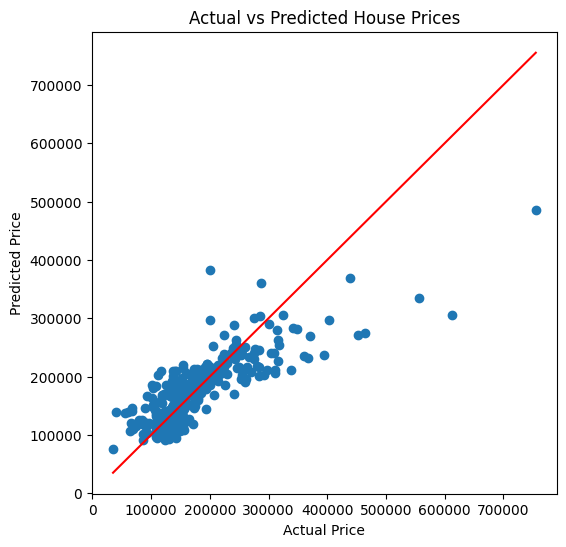

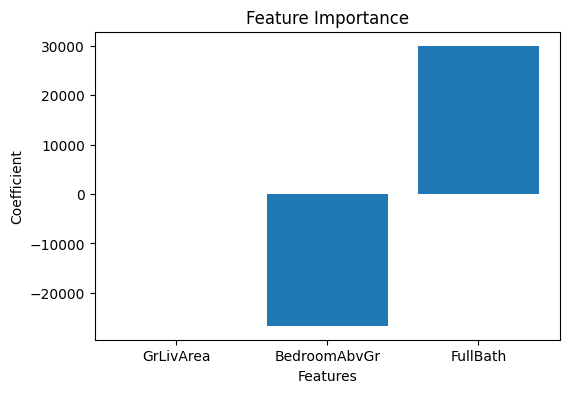

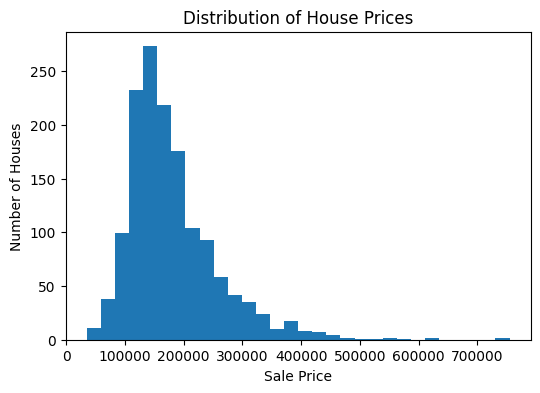

In [2]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset
df = pd.read_csv("train.csv")

# Select Features and Target
X = df[['GrLivArea', 'BedroomAbvGr', 'FullBath']]
y = df['SalePrice']

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("===== Model Performance =====")
print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

# Predict Sample House Price
sample_house = pd.DataFrame({
    'GrLivArea': [2000],
    'BedroomAbvGr': [3],
    'FullBath': [2]
})

predicted_price = model.predict(sample_house)
print("\nPredicted Price for Sample House: $", round(predicted_price[0], 2))

# ---------------- Graph 1 ----------------
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

# ---------------- Graph 2 ----------------
features = ['GrLivArea', 'BedroomAbvGr', 'FullBath']
coefficients = model.coef_

plt.figure(figsize=(6,4))
plt.bar(features, coefficients)
plt.xlabel("Features")
plt.ylabel("Coefficient")
plt.title("Feature Importance")
plt.show()

# ---------------- Graph 3 ----------------
plt.figure(figsize=(6,4))
plt.hist(df['SalePrice'], bins=30)
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")
plt.title("Distribution of House Prices")
plt.show()